# CreditWise Loan Approval System

## 1.Problem Statement

SecureTrust Bank aims to automate its loan approval process using machine learning to reduce manual bias and improve decision consistency. The objective is to develop a robust classification system that not only predicts loan approval but also evaluates multiple models, applies feature engineering, and optimizes performance through hyperparameter tuning. The project further analyzes feature importance and validates model decisions through explainability and feature reduction experiments. The final goal is to deliver a high-performing and interpretable model for reliable, data-driven lending decisions.

## 2.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## 3. Data Loading

In [2]:
df=pd.read_csv("loan_approval_data.csv")

In [3]:
df.head()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,1.0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2.0,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,NaN,Car,Semiurban,Graduate,NaN,Private,No
2,3.0,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,NaN,Urban,NaN,Female,Government,Yes
3,4.0,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,5.0,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,NaN,Graduate,Male,Private,Yes


## 4. Data Preprocessing

### 4.1 Data Overview

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Applicant_ID        950 non-null    float64
 1   Applicant_Income    950 non-null    float64
 2   Coapplicant_Income  950 non-null    float64
 3   Employment_Status   950 non-null    object 
 4   Age                 950 non-null    float64
 5   Marital_Status      950 non-null    object 
 6   Dependents          950 non-null    float64
 7   Credit_Score        950 non-null    float64
 8   Existing_Loans      950 non-null    float64
 9   DTI_Ratio           950 non-null    float64
 10  Savings             950 non-null    float64
 11  Collateral_Value    950 non-null    float64
 12  Loan_Amount         950 non-null    float64
 13  Loan_Term           950 non-null    float64
 14  Loan_Purpose        950 non-null    object 
 15  Property_Area       950 non-null    object 
 16  Educati

In [5]:
df.describe()

,Applicant_ID,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000
mean,501.220000,10852.571579,5082.455789,39.971579,1.474737,676.033684,1.950526,0.347263,9940.452632,24802.792632,20522.825263,48.000000
std,289.608451,5061.632859,2943.161570,11.139797,1.105067,71.346015,1.406246,0.144341,5860.736885,14345.696031,11504.142575,24.245322
min,1.000000,2009.000000,1.000000,21.000000,0.000000,550.000000,0.000000,0.100000,65.000000,36.000000,1015.000000,12.000000
25%,250.250000,6730.750000,2472.750000,30.250000,1.000000,616.250000,1.000000,0.220000,4760.250000,12698.250000,9806.250000,24.000000
50%,499.500000,10548.000000,5205.500000,40.000000,1.000000,678.000000,2.000000,0.340000,9880.500000,24321.000000,21210.500000,48.000000
75%,752.750000,15190.000000,7620.750000,49.000000,2.000000,737.000000,3.000000,0.480000,15074.500000,36947.000000,30263.000000,72.000000
max,1000.000000,19988.000000,9996.000000,59.000000,3.000000,799.000000,4.000000,0.600000,19996.000000,49954.000000,39995.000000,84.000000


In [6]:
df.isnull().sum()

Applicant_ID          50
Applicant_Income      50
Coapplicant_Income    50
Employment_Status     50
Age                   50
Marital_Status        50
Dependents            50
Credit_Score          50
Existing_Loans        50
DTI_Ratio             50
Savings               50
Collateral_Value      50
Loan_Amount           50
Loan_Term             50
Loan_Purpose          50
Property_Area         50
Education_Level       50
Gender                50
Employer_Category     50
Loan_Approved         50
dtype: int64

### 4.2 Data Cleaning

In [7]:
#Dropping irrelevant columns (Applicant_ID)
df=df.drop("Applicant_ID",axis=1)

In [8]:
#Handling missing values
from sklearn.impute import SimpleImputer

In [9]:
categorical_cols=df.select_dtypes(include=["object"]).columns
numerical_cols=df.select_dtypes(include=["float64"]).columns

In [10]:
num_imp=SimpleImputer(strategy="mean")
df[numerical_cols]=num_imp.fit_transform(df[numerical_cols])

In [11]:
cat_imp=SimpleImputer(strategy="most_frequent")
df[categorical_cols]=cat_imp.fit_transform(df[categorical_cols])

In [12]:
df.isnull().sum()

Applicant_Income      0
Coapplicant_Income    0
Employment_Status     0
Age                   0
Marital_Status        0
Dependents            0
Credit_Score          0
Existing_Loans        0
DTI_Ratio             0
Savings               0
Collateral_Value      0
Loan_Amount           0
Loan_Term             0
Loan_Purpose          0
Property_Area         0
Education_Level       0
Gender                0
Employer_Category     0
Loan_Approved         0
dtype: int64

In [13]:
df.head()

,Applicant_Income,Coapplicant_Income,Employment_Status,Age,Marital_Status,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,Loan_Term,Loan_Purpose,Property_Area,Education_Level,Gender,Employer_Category,Loan_Approved
0,17795.0,1387.0,Salaried,51.0,Married,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,84.0,Personal,Urban,Not Graduate,Female,Private,No
1,2860.0,2679.0,Salaried,46.0,Married,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,48.0,Car,Semiurban,Graduate,Male,Private,No
2,7390.0,2106.0,Salaried,25.0,Single,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,72.0,Business,Urban,Graduate,Female,Government,Yes
3,13964.0,8173.0,Salaried,40.0,Married,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,60.0,Business,Rural,Graduate,Female,Government,No
4,13284.0,4223.0,Self-employed,31.0,Single,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,72.0,Car,Urban,Graduate,Male,Private,Yes


## 5. Exploratory Data Analysis (EDA)

### 5.1 Class Distribution (Loan Approval Balance)

Text(0.5, 1.0, 'Loan approved or not')

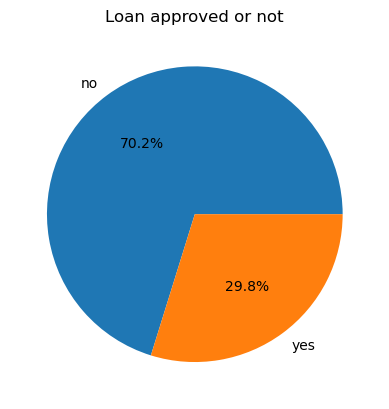

In [14]:
classes_count=df["Loan_Approved"].value_counts()
plt.pie(classes_count,labels=["no","yes"],autopct="%1.1f%%")
plt.title("Loan approved or not")

The dataset shows a moderate class imbalance, making precision and recall important evaluation metrics.

### 5.2 Categorical Feature Analysis (Gender, Education and Loan Purpose)

[Text(0, 0, '621'), Text(0, 0, '379')]

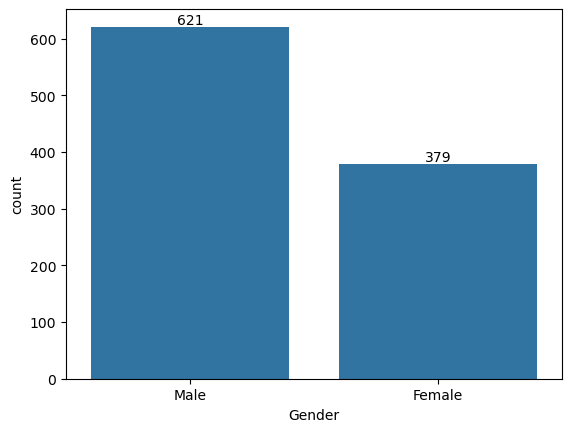

In [15]:
#analyze category
gender_count=df["Gender"].value_counts()
ax=sns.barplot(gender_count)
ax.bar_label(ax.containers[0])

The dataset contains more applicants from one gender category, indicating an uneven demographic distribution.

[Text(0, 0, '722'), Text(0, 0, '278')]

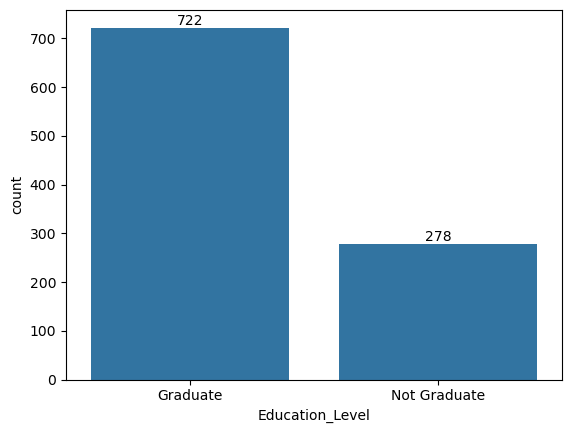

In [16]:
edu_count=df["Education_Level"].value_counts()
ax=sns.barplot(edu_count)
ax.bar_label(ax.containers[0])

Graduates represent the majority of applicants, suggesting higher participation from educated individuals in loan applications.

[Text(0, 0, '252'),
 Text(0, 0, '199'),
 Text(0, 0, '190'),
 Text(0, 0, '181'),
 Text(0, 0, '178')]

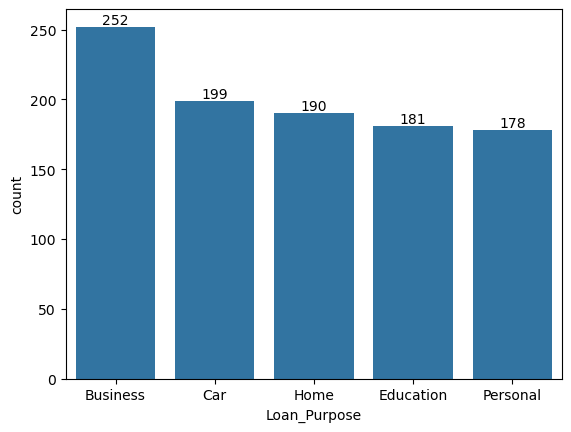

In [17]:
loanpurp_count=df["Loan_Purpose"].value_counts()
ax=sns.barplot(loanpurp_count)
ax.bar_label(ax.containers[0])

In [18]:
df["Loan_Purpose"].value_counts(normalize=True)*100

Loan_Purpose
Business     25.2
Car          19.9
Home         19.0
Education    18.1
Personal     17.8
Name: proportion, dtype: float64

Loan purposes are fairly distributed, with Business (25.2%) being the most common, followed by Car (19.9%), Home (19.0%), Education (18.1%), and Personal (17.8%).

### 5.3 Income Distribution (hue=Loan_Approved)

<Axes: xlabel='Applicant_Income', ylabel='Count'>

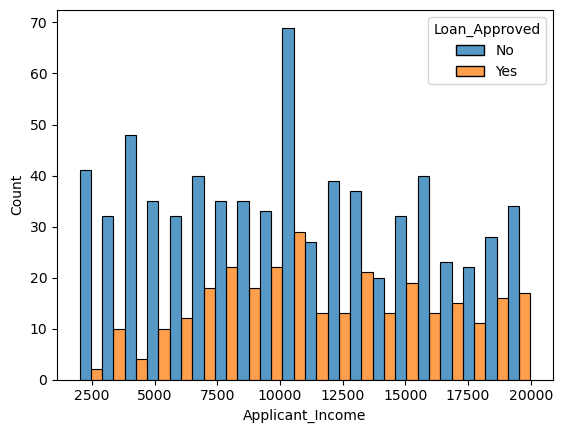

In [19]:
sns.histplot(
    data=df,
    x="Applicant_Income",
    bins=20,
    hue="Loan_Approved",
    multiple="dodge"
)

Applicant income distributions overlap across approval classes, indicating income alone is not a strong separating factor.

### 5.4 Outlier Detection (Boxplots)

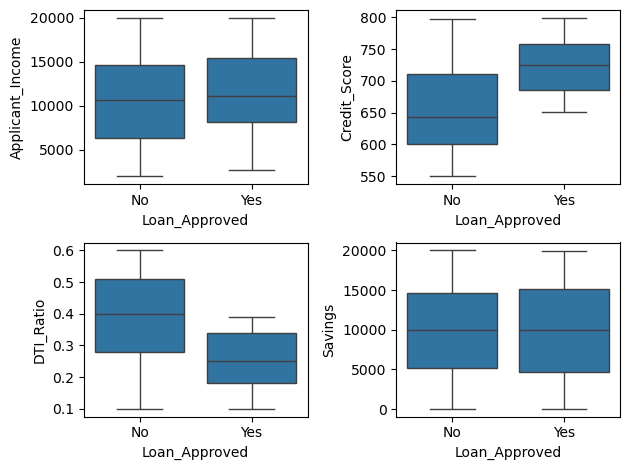

In [20]:
#checking outliers for diff cols
fig,axes=plt.subplots(2,2)
sns.boxplot(ax=axes[0,0],data=df,y="Applicant_Income",x="Loan_Approved")
sns.boxplot(ax=axes[0,1],data=df,y="Credit_Score",x="Loan_Approved")
sns.boxplot(ax=axes[1,0],data=df,y="DTI_Ratio",x="Loan_Approved")
sns.boxplot(ax=axes[1,1],data=df,y="Savings",x="Loan_Approved")
fig.tight_layout()

The numerical features show fairly consistent distributions across classes with no prominent outliers affecting the data.

## 6. Encoding Categorical Variables

In [21]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
le=LabelEncoder()
df["Education_Level"]=le.fit_transform(df["Education_Level"])
df["Loan_Approved"]=le.fit_transform(df["Loan_Approved"])

In [22]:
cols=["Employment_Status","Marital_Status","Loan_Purpose","Property_Area","Gender","Employer_Category"]
ohe=OneHotEncoder(drop="first",sparse_output=False,handle_unknown="ignore")
encoded=ohe.fit_transform(df[cols])
encoded

array([[1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [1., 0., 0., ..., 0., 1., 0.]])

In [23]:
encoded_df=pd.DataFrame(encoded,columns=ohe.get_feature_names_out(cols),index=df.index)
df=pd.concat([df.drop(columns=cols),encoded_df],axis=1)

In [24]:
df.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
0,17795.0,1387.0,51.0,0.0,637.0,4.0,0.53,19403.0,45638.0,16619.0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
1,2860.0,2679.0,46.0,3.0,621.0,2.0,0.30,2580.0,49272.0,38687.0,...,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
2,7390.0,2106.0,25.0,2.0,674.0,4.0,0.20,13844.0,6908.0,27943.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
3,13964.0,8173.0,40.0,2.0,579.0,3.0,0.31,9553.0,10844.0,27819.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,13284.0,4223.0,31.0,2.0,721.0,1.0,0.29,9386.0,37629.0,12741.0,...,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 28 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Applicant_Income                 1000 non-null   float64
 1   Coapplicant_Income               1000 non-null   float64
 2   Age                              1000 non-null   float64
 3   Dependents                       1000 non-null   float64
 4   Credit_Score                     1000 non-null   float64
 5   Existing_Loans                   1000 non-null   float64
 6   DTI_Ratio                        1000 non-null   float64
 7   Savings                          1000 non-null   float64
 8   Collateral_Value                 1000 non-null   float64
 9   Loan_Amount                      1000 non-null   float64
 10  Loan_Term                        1000 non-null   float64
 11  Education_Level                  1000 non-null   int64  
 12  Loan_Approved        

## 7. Feature Correlation Analysis

In [26]:
num_cols=df.select_dtypes(include="number")
corr_matrix=num_cols.corr()

In [27]:
num_cols.corr()["Loan_Approved"].sort_values(ascending=False)

Loan_Approved                      1.000000
Credit_Score                       0.451175
Applicant_Income                   0.119796
Employer_Category_MNC              0.069049
Loan_Purpose_Personal              0.034043
Marital_Status_Single              0.030182
Property_Area_Urban                0.025963
Collateral_Value                   0.021868
Coapplicant_Income                 0.004230
Loan_Purpose_Home                  0.002118
Employment_Status_Self-employed   -0.001337
Employer_Category_Private         -0.003347
Property_Area_Semiurban           -0.012967
Savings                           -0.013437
Loan_Purpose_Education            -0.016684
Employer_Category_Unemployed      -0.021468
Age                               -0.022343
Dependents                        -0.023811
Existing_Loans                    -0.034794
Employer_Category_Government      -0.039187
Employment_Status_Salaried        -0.041428
Employment_Status_Unemployed      -0.044464
Education_Level                 

## 8. Train-Test Split & Scaling

In [28]:
#Feature-target split
X=df.drop("Loan_Approved",axis=1)
y=df["Loan_Approved"]

In [29]:
#Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

In [30]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Credit_Score,Existing_Loans,DTI_Ratio,Savings,Collateral_Value,Loan_Amount,...,Loan_Purpose_Education,Loan_Purpose_Home,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed
29,5890.000000,8041.0,31.000000,0.0,603.000000,0.000000,0.11,11906.0,8150.000000,29287.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
535,4779.000000,529.0,50.000000,0.0,614.000000,0.000000,0.21,5369.0,5430.000000,14786.000000,...,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0
695,10852.571579,8927.0,36.000000,0.0,584.000000,4.000000,0.22,3186.0,24802.792632,20522.825263,...,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0
557,2384.000000,2113.0,39.971579,1.0,726.000000,4.000000,0.34,11882.0,48542.000000,13312.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
836,5228.000000,5249.0,42.000000,1.0,676.033684,1.950526,0.18,17669.0,24802.792632,13906.000000,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [31]:
#Scaling
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [32]:
X_train_scaled

array([[-1.01234556e+00,  1.02716377e+00, -8.22511453e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.23639141e+00, -1.59187898e+00,  9.15886794e-01, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.15862490e-02,  1.33606578e+00, -3.65038230e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       ...,
       [-2.27277589e-01,  3.50089621e-01, -8.22511453e-01, ...,
        -4.13887756e-01,  1.16316000e+00, -3.07231582e-01],
       [ 1.12970221e+00, -4.64700438e-01,  1.19037073e+00, ...,
        -4.13887756e-01, -8.59726954e-01, -3.07231582e-01],
       [-1.75526629e+00,  1.43417276e-02,  9.40348249e-04, ...,
         2.41611400e+00, -8.59726954e-01, -3.07231582e-01]])

## 9. Baseline Model Development
Baseline algorithm comparison to identify strong simple models.

### 9.1 Logistic Regression

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)

#evaluation
print("Logistic Regresion Model")
print("Precision",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

Logistic Regresion Model
Precision 0.7833333333333333
recall_score 0.7704918032786885
f1_score 0.7768595041322314
accuracy_score 0.865
confusion_matrix [[126  13]
 [ 14  47]]


### 9.2 K-Nearest Neighbors (KNN)

In [34]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
y_pred=knn.predict(X_test_scaled)
#evaluation
print("KNN Model")
print("Precision",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

KNN Model
Precision 0.6274509803921569
recall_score 0.5245901639344263
f1_score 0.5714285714285714
accuracy_score 0.76
confusion_matrix [[120  19]
 [ 29  32]]


### 9.3 Naive Bayes

In [35]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred=nb.predict(X_test_scaled)
#evaluation
print("Naive Bayes Model")
print("Precision",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

Naive Bayes Model
Precision 0.8035714285714286
recall_score 0.7377049180327869
f1_score 0.7692307692307693
accuracy_score 0.865
confusion_matrix [[128  11]
 [ 16  45]]


### 9.4 Model Comparison Table

In [36]:
comparison = pd.DataFrame({

"Model":[
"Logistic Regression",
"KNN",
"Naive Bayes"
],

"Precision":[0.783,0.627, 0.803],

"Recall":[0.770,0.524,0.737],

"F1 Score":[0.776,0.571,0.769],

"Accuracy":[ 0.865,0.76,0.865],

})

comparison.sort_values(by="F1 Score",ascending=False,ignore_index=True)

,Model,Precision,Recall,F1 Score,Accuracy
0,Logistic Regression,0.783,0.770,0.776,0.865
1,Naive Bayes,0.803,0.737,0.769,0.865
2,KNN,0.627,0.524,0.571,0.760


### 9.5 Baseline Model Conclusion 
Logistic Regression performed best among basic models with a strong balance between precision and recall, making it a reliable initial benchmark.

## 10. Advanced Model: Random Forest

### 10.1 Baseline Random Forest Model

In [37]:
#This model uses default parameters and serves as the reference model.
from sklearn.ensemble import RandomForestClassifier

rf=RandomForestClassifier(random_state=42)
rf.fit(X_train_scaled,y_train)
y_pred = rf.predict(X_test_scaled)
#evaluation
print("Baseline Random Forest")
print("Precision",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

Baseline Random Forest
Precision 0.8387096774193549
recall_score 0.8524590163934426
f1_score 0.8455284552845529
accuracy_score 0.905
confusion_matrix [[129  10]
 [  9  52]]


### 10.2 Hyperparameter Tuned Random Forest

In [38]:
from sklearn.model_selection import GridSearchCV

#parameter grid
param_grid={
    'n_estimators': [50, 100, 200], # Number of trees
    'max_depth': [None, 10, 20, 30], # Depth of the trees
    'min_samples_split': [2, 5, 10]  # Minimum samples to split a node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, # 5-fold cross-validation
                           scoring='precision', 
                           n_jobs=-1)

# Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)


# Use the best parameters found by GridSearchCV
best_rf=grid_search.best_estimator_

# Final Evaluation
y_pred_best=best_rf.predict(X_test_scaled)
print("\nHyperparameter Tuned Random Forest")
print("Precision",precision_score(y_test,y_pred_best))
print("recall_score",recall_score(y_test,y_pred_best))
print("F1 Score:", f1_score(y_test,y_pred_best))
print("Accuracy:", accuracy_score(y_test,y_pred_best))
print("confusion_matrix",confusion_matrix(y_test,y_pred_best))

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}
Best Cross-Validation Score: 0.8942838433654554

Hyperparameter Tuned Random Forest
Precision 0.8412698412698413
recall_score 0.8688524590163934
F1 Score: 0.8548387096774194
Accuracy: 0.91
confusion_matrix [[129  10]
 [  8  53]]


### 10.3 Tuned Random Forest with Class Imbalance Handling

In [39]:
#parameter grid
param_grid = {
    'n_estimators': [50, 100, 200], # Number of trees
    'max_depth': [None, 10, 20, 30], # Depth of the trees
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
   'class_weight':['balanced']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42), 
                           param_grid=param_grid, 
                           cv=5, # 5-fold cross-validation
                           scoring='precision', 
                           n_jobs=-1)

# Fit the grid search
grid_search.fit(X_train_scaled, y_train)

# Best parameters and score
print("Best Parameters:", grid_search.best_params_)
print("Best Cross-Validation Score:", grid_search.best_score_)

# Use the best parameters found by GridSearchCV
balance_rf = grid_search.best_estimator_

# Final Evaluation
y_pred_balance = balance_rf.predict(X_test_scaled)
print("\nTuned Random Forest with Class Imbalance Handling")
print("Precision",precision_score(y_test,y_pred_balance))
print("recall_score",recall_score(y_test,y_pred_balance))
print("F1 Score:", f1_score(y_test,y_pred_balance))
print("Accuracy:", accuracy_score(y_test,y_pred_balance))
print("confusion_matrix",confusion_matrix(y_test,y_pred_balance))

Best Parameters: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation Score: 0.8864135585787386

Tuned Random Forest with Class Imbalance Handling
Precision 0.819672131147541
recall_score 0.819672131147541
F1 Score: 0.819672131147541
Accuracy: 0.89
confusion_matrix [[128  11]
 [ 11  50]]


### 10.4 Model Comparison Table

In [40]:
comparison = pd.DataFrame({

"Model":[
"Baseline Random Forest",
"Hyperparameter Tuned Random Forest",
"Tuned RF + Class Weight"
],



"Precision":[0.838,0.841,0.819],

"Recall":[0.852,0.868,0.819],

"F1 Score":[0.845,0.854,0.819],

"Accuracy":[0.905,0.91,0.89]

})

comparison.sort_values(by="F1 Score",ascending=False,ignore_index=True)

,Model,Precision,Recall,F1 Score,Accuracy
0,Hyperparameter Tuned Random Forest,0.841,0.868,0.854,0.910
1,Baseline Random Forest,0.838,0.852,0.845,0.905
2,Tuned RF + Class Weight,0.819,0.819,0.819,0.890


### 10.5 Random Forest Model Conclusion 

Observations:  
• Hyperparameter tuning improved model performance compared to baseline.  
• The tuned Random Forest achieved the highest F1-score with a strong precision–recall balance.  
• Applying class_weight='balanced' led to a slight drop in performance.    
• This indicates that class imbalance was not significant enough to require additional handling.    

Key Learning:  
Hyperparameter tuning had a greater impact on performance than class imbalance handling for this dataset.   

Final Model Selection:  
The Hyperparameter Tuned Random Forest was selected as the final model due to its superior F1-score and balanced performance, making it most suitable for reliable loan approval predictions.  

## 11. Feature Engineering Experiment

### 11.1 Creation of Engineered Features

In [41]:
#Debt-to-Income Squared
df["DTI_Ratio_sq"]=df["DTI_Ratio"]**2
#Credit Score Squared
df["Credit_Score_sq"]=df["Credit_Score"]**2
X=df.drop(columns=["Loan_Approved","Credit_Score","DTI_Ratio"])
y=df["Loan_Approved"]
#Train Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#Scaling
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [42]:
X_train.head()

,Applicant_Income,Coapplicant_Income,Age,Dependents,Existing_Loans,Savings,Collateral_Value,Loan_Amount,Loan_Term,Education_Level,...,Loan_Purpose_Personal,Property_Area_Semiurban,Property_Area_Urban,Gender_Male,Employer_Category_Government,Employer_Category_MNC,Employer_Category_Private,Employer_Category_Unemployed,DTI_Ratio_sq,Credit_Score_sq
29,5890.000000,8041.0,31.000000,0.0,0.000000,11906.0,8150.000000,29287.000000,12.0,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0121,363609.000000
535,4779.000000,529.0,50.000000,0.0,0.000000,5369.0,5430.000000,14786.000000,72.0,1,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0441,376996.000000
695,10852.571579,8927.0,36.000000,0.0,4.000000,3186.0,24802.792632,20522.825263,48.0,1,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0484,341056.000000
557,2384.000000,2113.0,39.971579,1.0,4.000000,11882.0,48542.000000,13312.000000,24.0,0,...,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.1156,527076.000000
836,5228.000000,5249.0,42.000000,1.0,1.950526,17669.0,24802.792632,13906.000000,84.0,0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0324,457021.542187


### 11.2 Model Training with Engineered Features

In [43]:
#model 1
#logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score
log_model=LogisticRegression()
log_model.fit(X_train_scaled,y_train)
y_pred=log_model.predict(X_test_scaled)

#evaluation
print("Logistic Regresion Model")
print("Precision",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

Logistic Regresion Model
Precision 0.7903225806451613
recall_score 0.8032786885245902
accuracy_score 0.875
f1_score 0.7967479674796748
confusion_matrix [[126  13]
 [ 12  49]]


In [44]:
#model 2
#KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)
y_pred=knn.predict(X_test_scaled)
#evaluation
print("KNN Model")
print("Precision",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

KNN Model
Precision 0.62
recall_score 0.5081967213114754
accuracy_score 0.755
f1_score 0.5585585585585585
confusion_matrix [[120  19]
 [ 30  31]]


In [45]:
#model 3
#Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train_scaled, y_train)
y_pred=nb.predict(X_test_scaled)
#evaluation
print("Naive Bayes Model")
print("Precision",precision_score(y_test,y_pred))
print("recall_score",recall_score(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))
print("f1_score",f1_score(y_test,y_pred))
print("confusion_matrix",confusion_matrix(y_test,y_pred))

Naive Bayes Model
Precision 0.7833333333333333
recall_score 0.7704918032786885
accuracy_score 0.865
f1_score 0.7768595041322314
confusion_matrix [[126  13]
 [ 14  47]]


### 11.3 Model Comparison Table

In [46]:
comparison_after = pd.DataFrame({

"Model":[
"Logistic Regression",
"KNN",
"Naive Bayes"
],

"Precision Before":[0.783,0.627, 0.803],
"Precision After":[0.79,0.62, 0.783],

"Recall Before":[0.770,0.524,0.737],
"Recall After":[0.803,0.508,0.770],

"F1 Score Before":[0.776,0.571,0.769],
"F1 Score After":[0.796,0.558,0.776],

"Accuracy Before":[ 0.865,0.76,0.865],
"Accuracy After":[ 0.875,0.755,0.865]

})

comparison_after.sort_values(by="F1 Score After",ascending=False,ignore_index=True)

,Model,Precision Before,Precision After,Recall Before,Recall After,F1 Score Before,F1 Score After,Accuracy Before,Accuracy After
0,Logistic Regression,0.783,0.790,0.770,0.803,0.776,0.796,0.865,0.875
1,Naive Bayes,0.803,0.783,0.737,0.770,0.769,0.776,0.865,0.865
2,KNN,0.627,0.620,0.524,0.508,0.571,0.558,0.760,0.755


### 11.4 Feature Engineering Conclusion 
Feature engineering using squared credit and debit score features improved Logistic Regression performance, while Naive Bayes showed minimal gains and KNN slightly declined. Logistic Regression was therefore selected as the best baseline model for final comparison with the tuned Random Forest model.

### 11.5 Feature Engineering Scope

Feature engineering was evaluated on baseline models where its impact is more pronounced. Tree-based models like Random Forest inherently capture non-linear relationships, reducing the need for manual feature transformations.

## 12. Final Model Comparison & Selection

### 12.1 Comparison of Top Models  
Logistic Regression (with Feature Engineering)  
Tuned Random Forest 

In [47]:
best_model= pd.DataFrame({

"Final Candidate Model":[
"Logistic Regression FE",
"Tuned Random Forest"
],

"Precision":[0.79,0.841],

"Recall":[0.803,0.868],
 
"F1 Score":[0.796,0.854],

"Accuracy":[0.875,0.91]
})

best_model.sort_values(by="F1 Score",ascending=False,ignore_index=True)

,Final Candidate Model,Precision,Recall,F1 Score,Accuracy
0,Tuned Random Forest,0.841,0.868,0.854,0.910
1,Logistic Regression FE,0.790,0.803,0.796,0.875


### 12.2 Final Model Selection

The Tuned Random Forest outperformed Logistic Regression with Feature Engineering across all evaluation metrics, achieving the highest F1-score (0.854) and accuracy (0.91). Therefore, Tuned Random Forest was selected as the final production model due to its superior predictive performance and better balance between precision and recall.

## 13. Model Explainability & Insights

### 13.1 Feature Importance Analysis

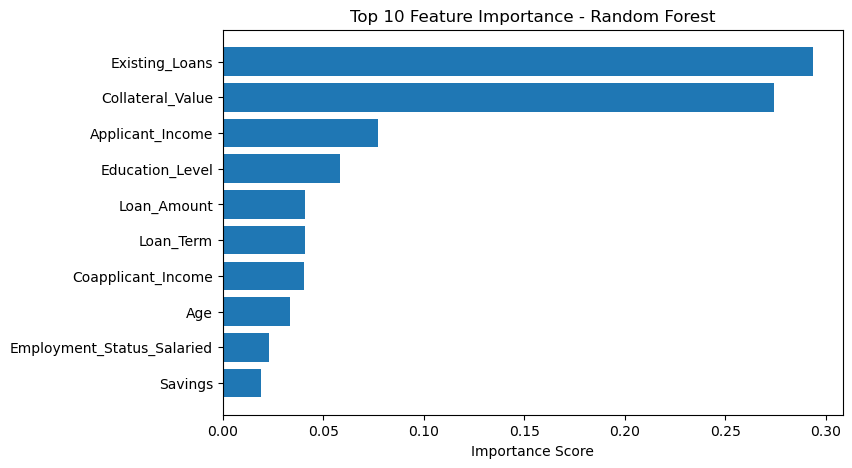

In [48]:
feature_importance =best_rf.feature_importances_

features = X.columns

importance_df = pd.DataFrame({
    "Feature": features,
    "Importance": feature_importance
}).sort_values(by="Importance", ascending=False)

top_features = importance_df.head(10)

#plot
plt.figure(figsize=(8,5))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 10 Feature Importance - Random Forest")
plt.xlabel("Importance Score")
plt.show()

### 13.2 Top Contributing Features
1.Existing_Loans is the most influential feature, indicating current liabilities strongly impact loan approval decisions.  
2.Collateral_Value plays a major role, suggesting secured assets significantly reduce risk.  
3.Income-related features (Applicant_Income, Coapplicant_Income) are key indicators of repayment capacity.  
4.Loan attributes (Loan_Amount, Loan_Term) influence approval due to repayment burden.  
5.Demographic features (Age, Education_Level) have moderate influence.  

### 13.3 Key Drivers of Loan Approval  
**1.Financial Strength**  
->Applicant_Income  
->Coapplicant_Income  
->Savings  
**2.Risk Indicators**  
->Existing_Loans  
->Loan_Amount  
->Loan_Term  
->Security / Assets  
->Collateral_Value  
**3.Demographics**  
->Age  
->Education_Level  
->Employment_Status  

### 13.4 Business Insight 
1.Applicants with higher existing loans are riskier  
2.Higher collateral value increases approval likelihood  
3.Stable income sources improve trustworthiness  
4.Longer loan terms and higher loan amounts increase risk  

### 14. Feature Engineering Observation  
**Impact of Engineered Features**  
Despite moderate correlation, engineered features like credit_score_squared and debt_to_income_squared did not appear among top important features.  
**Interpretation of Results**  
1.Random Forest already captures nonlinear relationships  
2.Original features provided sufficient predictive signal  
3.Manual nonlinear transformations added limited value  

## 15. Feature Reduction Experiment Setup 
To validate the importance of top contributing features, a reduced Random Forest model was trained using only the top 10 features while keeping the hyperparameters consistent with the tuned model.  

### 15.1 Experiment Setup

In [49]:
top_features = importance_df.head(10)["Feature"]

X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

rf_top = RandomForestClassifier(max_depth=None, min_samples_split= 2, n_estimators= 50, random_state=42,class_weight='balanced')
rf_top.fit(X_train_top, y_train)
#The reduced model was trained using the same optimized hyperparameters obtained from tuning.

y_pred_top = rf_top.predict(X_test_top)

print("Top Features Model:")
print("Precision:", precision_score(y_test, y_pred_top))
print("Recall:", recall_score(y_test, y_pred_top))
print("F1:", f1_score(y_test, y_pred_top))
print("Accuracy:", accuracy_score(y_test, y_pred_top))
print("confusion matrix",confusion_matrix(y_test, y_pred_top))
print(pd.Series(y_pred_top).value_counts())

Top Features Model:
Precision: 0.75
Recall: 0.09836065573770492
F1: 0.17391304347826086
Accuracy: 0.715
confusion matrix [[137   2]
 [ 55   6]]
0    192
1      8
Name: count, dtype: int64


### 15.2 Model Performance Comparison

In [50]:
best_model= pd.DataFrame({

"Model Version":[
"Top 10 Features(no balancing)",
"Top 10 Features (Balanced)"
],

"Precision":[0.38,0.75],

"Recall":[0.08,0.09],

"F1 Score":[0.13,0.17],

"Accuracy":[0.68,0.71]
})
best_model

,Model Version,Precision,Recall,F1 Score,Accuracy
0,Top 10 Features(no balancing),0.38,0.08,0.13,0.68
1,Top 10 Features (Balanced),0.75,0.09,0.17,0.71


### 15.3 Impact of Feature Reduction

Compared to the tuned Random Forest (Precision: 0.84, Recall: 0.87, F1: 0.85), the reduced models showed a drastic drop in performance, especially in recall (0.08–0.09).  
Although class balancing improved precision, the models failed to correctly identify positive cases, leading to very low F1 scores.

### 15.4 Feature Reduction Conclusion

The reduced feature models performed significantly worse than the full-feature tuned Random Forest, confirming that important feature interactions were lost.
Class imbalance handling did not resolve the issue, indicating that the performance drop was mainly due to loss of critical information.  

Therefore, the full feature set is essential for maintaining strong predictive performance.

## 16. Overall Conclusion

The CreditWise Loan Approval System was developed to automate loan approval decisions using machine learning. Multiple models were evaluated, and a hyperparameter-tuned Random Forest was selected as the final model due to its superior F1-score and balanced performance.  

Feature importance analysis revealed that financial strength, existing liabilities, and collateral value are the key drivers of loan approval decisions. Experiments with feature engineering and feature reduction showed that the original feature set provides the most reliable predictive performance.  

Overall, the model demonstrates strong capability in identifying both low-risk and high-risk applicants, making it suitable for real-world loan decision support.  